
=== SUMMARY STATISTICS: GLOBAL PANEL ===
                                     count   mean    std      min    50%  \
Wealth_Ratio_Top10_to_Bottom50      1204.0  15.75  85.39 -2394.67  12.81   
General Government Debt (% of GDP)  1170.0  59.49  39.57     2.69  52.64   
GDP growth (annual %)               1204.0   3.08   3.58   -16.04   3.04   
Gross capital formation (% of GDP)  1198.0  24.17   5.48    11.89  23.25   
Inflation (Annual %)                1191.0   4.71   9.91    -4.45   2.49   
Population growth (annual %)        1204.0   0.72   1.12    -2.26   0.56   

                                        max  
Wealth_Ratio_Top10_to_Bottom50      1194.17  
General Government Debt (% of GDP)   258.37  
GDP growth (annual %)                 24.62  
Gross capital formation (% of GDP)    53.70  
Inflation (Annual %)                 197.41  
Population growth (annual %)          11.59  

=== SUMMARY STATISTICS: OECD (ADVANCED) ===
                                    count   mean    std   

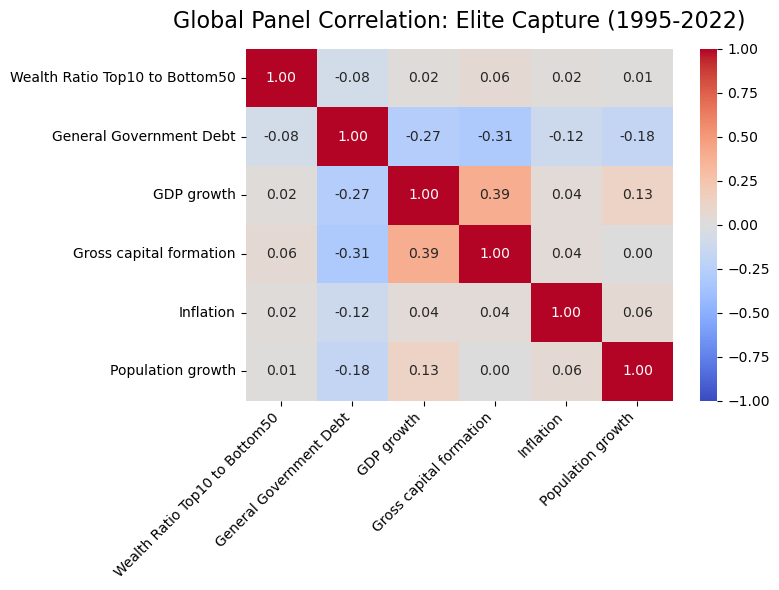

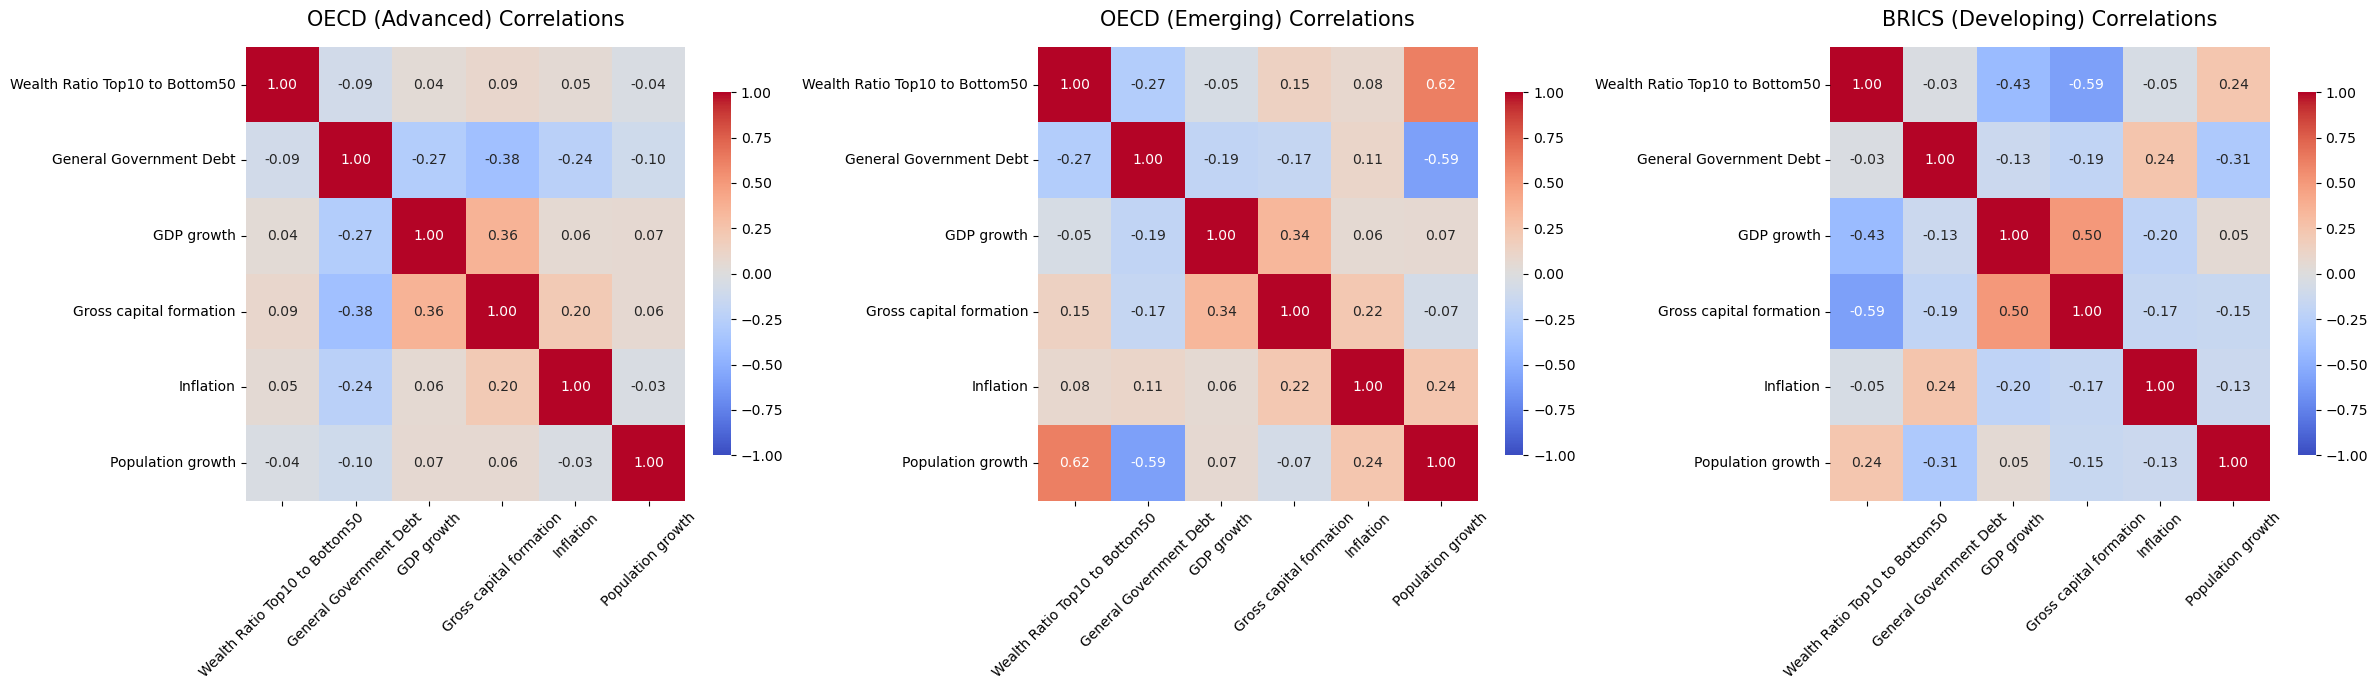


=== ADVANCED PANEL UNIT ROOT TESTS (ADF & PP) ===
H0: The series has a unit root (NON-STATIONARY).
H1: The series is STATIONARY (p < 0.05).
-----------------------------------------------------------------------------------------------
Variable                                 | ADF p-value     | PP p-value      | Joint Conclusion
-----------------------------------------------------------------------------------------------
Wealth_Ratio_Top10_to_Bottom50           | <0.0001         | <0.0001         | ROBUST STATIONARY
General Government Debt (% of GDP)       | <0.0001         | <0.0001         | ROBUST STATIONARY
GDP growth (annual %)                    | <0.0001         | <0.0001         | ROBUST STATIONARY
Gross capital formation (% of GDP)       | <0.0001         | <0.0001         | ROBUST STATIONARY
Inflation (Annual %)                     | <0.0001         | <0.0001         | ROBUST STATIONARY
Population growth (annual %)             | <0.0001         | <0.0001         | ROBUST 

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from arch.unitroot import PhillipsPerron
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# ==============================================================================
# 1. GLOBAL CONFIGURATION & DATA LOADING
# ==============================================================================
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
master_file = PROCESSED_DIR / "master_panel_data.csv"

df = pd.read_csv(master_file)
df = df.set_index(['Country Name', 'Year'])

BRICS_NATIONS = ["Brazil", "Russia", "India", "China", "Egypt", "United Arab Emirates"]
OECD_EMERGING = ["Chile", "Colombia", "Costa Rica", "Turkey", "Hungary", "Poland"]

def categorize_economy(country):
    if country in BRICS_NATIONS: return 'BRICS (Developing)'
    elif country in OECD_EMERGING: return 'OECD (Emerging)'
    else: return 'OECD (Advanced)'

df['Economic_Bloc'] = [categorize_economy(c) for c, y in df.index]

# Create Elite Capture Ratio
TOP_10_COL = 'Wealth Inequality (Top 10%)'
BOTTOM_50_COL = 'Wealth Inequality (Bottom 50%)'
df['Wealth_Ratio_Top10_to_Bottom50'] = df[TOP_10_COL] / df[BOTTOM_50_COL]
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Define Core Metrics for Wealth Analysis (Matching the control set from the GDP models)
CORE_METRICS = [
    'Wealth_Ratio_Top10_to_Bottom50', 
    'General Government Debt (% of GDP)', 
    'GDP growth (annual %)',
    'Gross capital formation (% of GDP)',
    'Inflation (Annual %)',
    'Population growth (annual %)'
]

# ==============================================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA) FUNCTIONS
# ==============================================================================
def generate_summary_statistics(data, metrics):
    """Prints descriptive statistics globally, then segmented by economic bloc."""
    print(f"\n{'='*60}\n=== SUMMARY STATISTICS: GLOBAL PANEL ===\n{'='*60}")
    print(data[metrics].describe().round(2).T[['count', 'mean', 'std', 'min', '50%', 'max']])
    
    blocs = ['OECD (Advanced)', 'OECD (Emerging)', 'BRICS (Developing)']
    for bloc in blocs:
        print(f"\n{'='*60}\n=== SUMMARY STATISTICS: {bloc.upper()} ===\n{'='*60}")
        bloc_data = data[data['Economic_Bloc'] == bloc][metrics]
        print(bloc_data.describe().round(2).T[['count', 'mean', 'std', 'min', '50%', 'max']])

def plot_correlation_matrices(data, metrics):
    """Plots a Global heatmap, followed by side-by-side bloc heatmaps."""
    # Clean up labels for plotting
    plot_labels = [m.replace(' (% of GDP)', '').replace(' (annual %)', '').replace(' (Annual %)', '').replace('_', ' ') for m in metrics]
    
    # 1. Global Correlation Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(data[metrics].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
                fmt=".2f", xticklabels=plot_labels, yticklabels=plot_labels)
    plt.title('Global Panel Correlation: Elite Capture (1995-2022)', fontsize=16, pad=15)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # 2. Bloc-Specific Correlation Matrices
    blocs = ['OECD (Advanced)', 'OECD (Emerging)', 'BRICS (Developing)']
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    for i, bloc in enumerate(blocs):
        bloc_data = data[data['Economic_Bloc'] == bloc][metrics]
        sns.heatmap(bloc_data.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
                    fmt=".2f", ax=axes[i], xticklabels=plot_labels, yticklabels=plot_labels, cbar_kws={"shrink": .8})
        axes[i].set_title(f'{bloc} Correlations', fontsize=15, pad=15)
        axes[i].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 3. ADVANCED STATIONARITY TESTING (ADF & PP)
# ==============================================================================
def panel_unit_root_tests(data, variables):
    """Executes both Augmented Dickey-Fuller (ADF) and Phillips-Perron (PP) tests."""
    print(f"\n{'='*95}")
    print("=== ADVANCED PANEL UNIT ROOT TESTS (ADF & PP) ===")
    print("H0: The series has a unit root (NON-STATIONARY).")
    print("H1: The series is STATIONARY (p < 0.05).")
    print("-" * 95)
    print(f"{'Variable':<40} | {'ADF p-value':<15} | {'PP p-value':<15} | {'Joint Conclusion'}")
    print("-" * 95)

    for var in variables:
        series = data[var].dropna()
        if len(series) < 30: 
            print(f"{var:<40} | INSUFFICIENT DATA FOR UNIT ROOT TEST")
            continue
            
        adf_pval = adfuller(series, autolag='AIC', regression='c')[1]
        pp_pval = PhillipsPerron(series, trend='c').pvalue
        
        adf_str = "<0.0001" if adf_pval < 0.0001 else f"{adf_pval:.4f}"
        pp_str = "<0.0001" if pp_pval < 0.0001 else f"{pp_pval:.4f}"
        
        if adf_pval < 0.05 and pp_pval < 0.05: conclusion = "ROBUST STATIONARY"
        elif adf_pval < 0.05 or pp_pval < 0.05: conclusion = "MIXED (Lean Stationary)"
        else: conclusion = "NON-STATIONARY"
            
        print(f"{var:<40} | {adf_str:<15} | {pp_str:<15} | {conclusion}")
    print("===============================================================================================\n")

# ==============================================================================
# 4. PIPELINE EXECUTION
# ==============================================================================
if __name__ == "__main__":
    generate_summary_statistics(df, CORE_METRICS)
    plot_correlation_matrices(df, CORE_METRICS)
    panel_unit_root_tests(df, CORE_METRICS)